# PHASE 1 - Dataset Exploration

Project: **An Evolving Fuzzy Reasoning System for Sensor Stream Anomaly Detection under Concept Drift**

Muc tieu cua notebook nay:
- Tai/kiem tra dataset AI4I 2020 Predictive Maintenance.
- Hieu cau truc du lieu, missing values, duplicate, class imbalance.
- Quan sat distribution va correlation co ban.
- Chon feature ung vien cho fuzzy system o phase sau.

**Chua thiet ke fuzzy rules trong Phase 1.**


## 0. Nguon du lieu chinh thuc

Nguon chinh thuc: UCI Machine Learning Repository - AI4I 2020 Predictive Maintenance Dataset, dataset ID 601.

Link: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

Trong project nay, file du lieu nen nam tai:

`data/ai4i2020.csv`

Neu file da co san trong folder `data/`, hay chay tiep cac cell ben duoi. Neu chua co, tai file `ai4i2020.csv` tu UCI va dat vao folder `data/`.


## 1. Kiem tra moi truong Python

Cell nay giup xac nhan cac thu vien can thiet da cai dung. Neu loi import, quay lai cai dependencies truoc khi tiep tuc.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
NumPy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.11.0
Seaborn: 0.13.2


## 2. Load dataset

Doc file CSV tu folder `data/`. Sau cell nay, chi can kiem tra dataset load duoc hay chua, chua ket luan gi ve fuzzy.


In [2]:
DATA_PATH = Path("..") / "data" / "ai4i2020.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Shape va columns

Kiem tra so dong, so cot va ten cot. Ghi lai ket qua de dua vao bao cao Phase 1.


In [3]:
print("Shape:", df.shape)
pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)})

Shape: (10000, 14)


,column,dtype
UDI,UDI,int64
Product ID,Product ID,object
Type,Type,object
Air temperature [K],Air temperature [K],float64
Process temperature [K],Process temperature [K],float64
Rotational speed [rpm],Rotational speed [rpm],int64
Torque [Nm],Torque [Nm],float64
Tool wear [min],Tool wear [min],int64
Machine failure,Machine failure,int64
TWF,TWF,int64


## 4. Missing values

Kiem tra du lieu thieu theo tung cot. Neu co missing values, chua xu ly ngay; dau tien can ghi nhan muc do thieu.


In [4]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = missing["missing_count"] / len(df) * 100
missing

,missing_count,missing_percent
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


## 5. Duplicate rows

Kiem tra dong trung lap. Neu co duplicate, can xem xet truoc khi huan luyen/evaluate o cac phase sau.


In [5]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(10))

Duplicate rows: 0


## 6. Class distribution

Target chinh tam thoi la `Machine failure`. Cac cot `TWF`, `HDF`, `PWF`, `OSF`, `RNF` la cac loai failure rieng. Phase nay chi quan sat imbalance, chua toi uu model.


In [6]:
target_col = "Machine failure"
failure_mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

target_distribution = df[target_col].value_counts().rename_axis(target_col).to_frame("count")
target_distribution["percent"] = target_distribution["count"] / len(df) * 100
display(target_distribution)

mode_distribution = df[failure_mode_cols].sum().sort_values(ascending=False).to_frame("count")
display(mode_distribution)

,count,percent
Machine failure,,
0,9661,96.61
1,339,3.39


,count
HDF,115
OSF,98
PWF,95
TWF,46
RNF,19


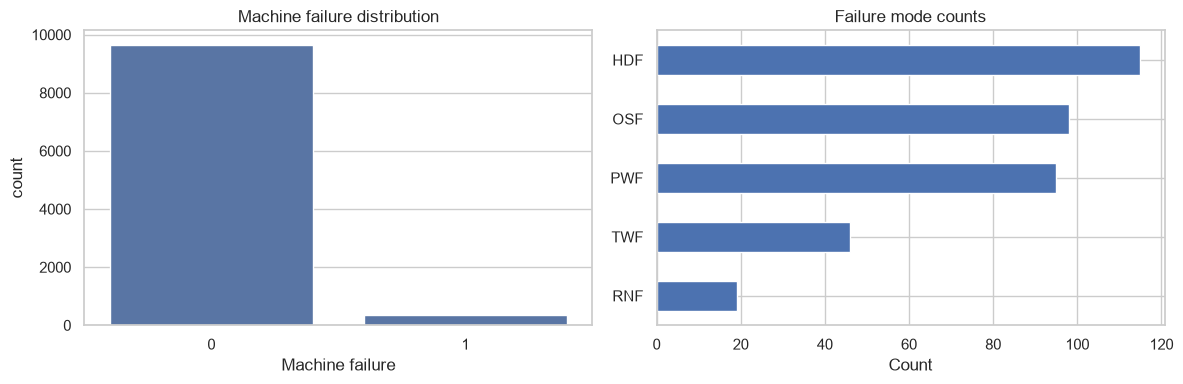

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x=target_col, ax=axes[0])
axes[0].set_title("Machine failure distribution")

mode_distribution.sort_values("count").plot(kind="barh", ax=axes[1], legend=False)
axes[1].set_title("Failure mode counts")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 7. Descriptive statistics

Xem thong ke cua cac feature cam bien/van hanh. Chu y min, max, mean, std de phase sau thiet ke membership functions hop ly.


In [8]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

df[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


## 8. Distribution cua numeric features

Quan sat distribution giup ta biet feature nao co khoang gia tri ro, lech manh, hoac co outlier. Day la dau vao quan trong cho Phase 2, nhung chua tao fuzzy sets o day.


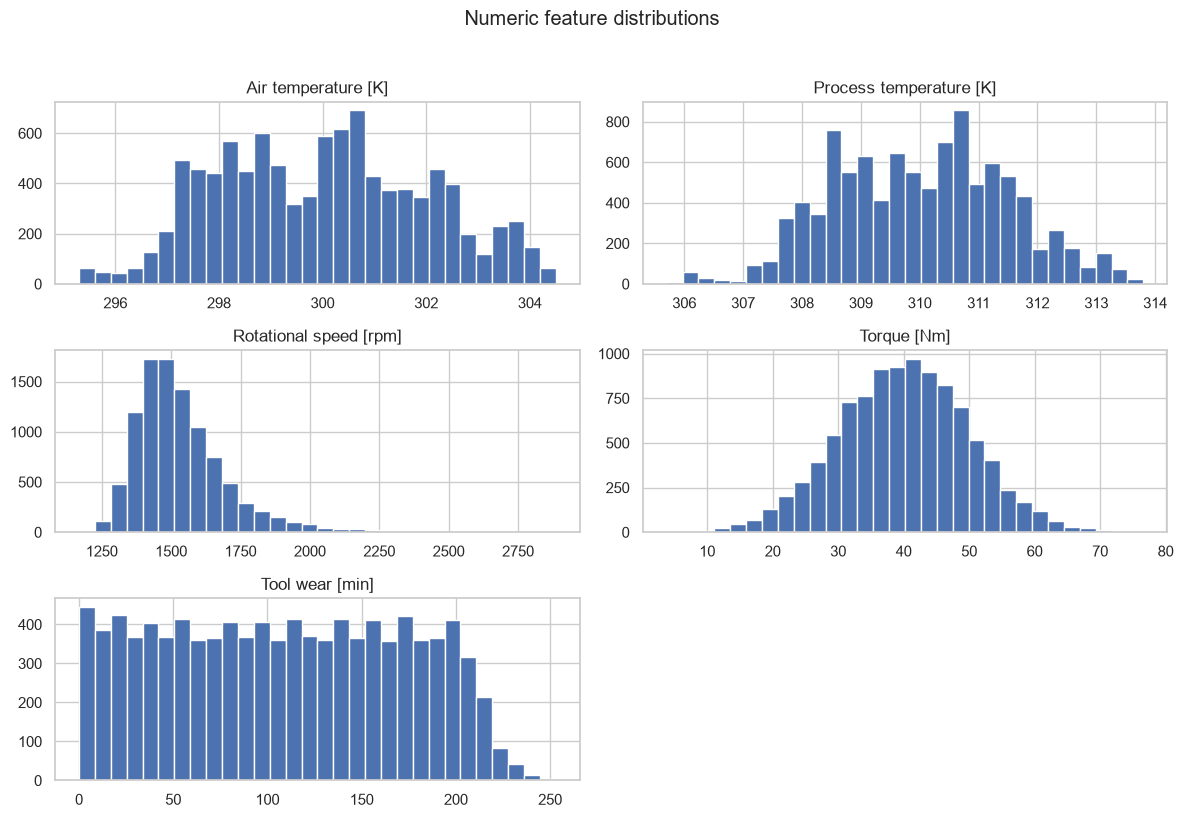

In [9]:
df[sensor_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Numeric feature distributions", y=1.02)
plt.tight_layout()
plt.show()

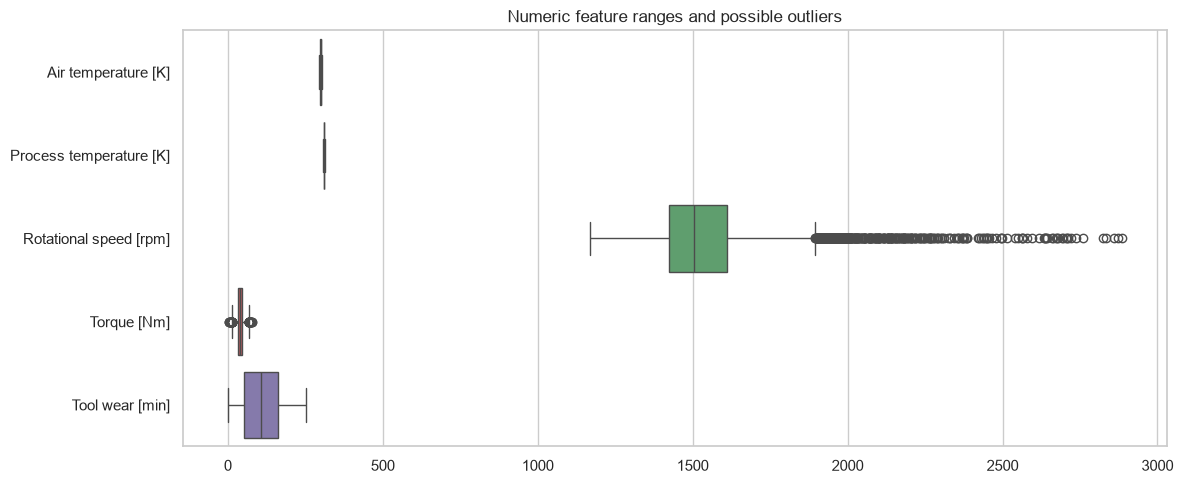

In [10]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[sensor_cols], orient="h")
plt.title("Numeric feature ranges and possible outliers")
plt.tight_layout()
plt.show()

## 9. Correlation

Kiem tra tuong quan giua cac numeric feature va target. Correlation khong chung minh quan he nhan qua, nhung giup chon feature ung vien ban dau.


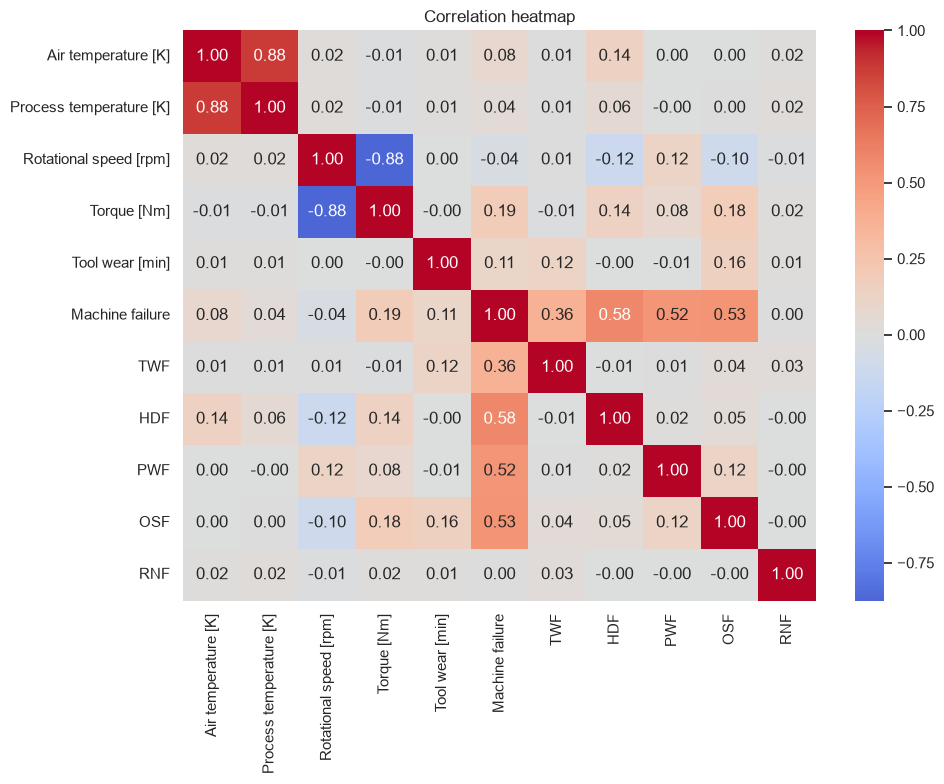

In [11]:
corr_cols = sensor_cols + [target_col] + failure_mode_cols
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [12]:
corr[target_col].drop(target_col).sort_values(key=lambda s: s.abs(), ascending=False).to_frame("corr_with_machine_failure")

,corr_with_machine_failure
HDF,0.575800
OSF,0.531083
PWF,0.522812
TWF,0.362904
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Rotational speed [rpm],-0.044188
Process temperature [K],0.035946
RNF,0.004516


## 10. So sanh feature theo target

Cell nay xem nhanh cac feature numeric khac nhau nhu the nao giua normal va failure. Do class failure thuong it, can doc ket qua can than.


In [13]:
df.groupby(target_col)[sensor_cols].agg(["mean", "median", "std", "min", "max"]).T

Machine failure                           0            1
Air temperature [K]     mean     299.973999   300.886431
                        median   300.000000   301.600000
                        std        1.990748     2.071473
                        min      295.300000   295.600000
                        max      304.500000   304.400000
Process temperature [K] mean     309.995570   310.290265
                        median   310.000000   310.400000
                        std        1.486846     1.363686
                        min      305.700000   306.100000
                        max      313.800000   313.700000
Rotational speed [rpm]  mean    1540.260014  1496.486726
                        median  1507.000000  1365.000000
                        std      167.394734   384.943547
                        min     1168.000000  1181.000000
                        max     2695.000000  2886.000000
Torque [Nm]             mean      39.629655    50.168142
                        median    39.900000    53.700000
                        std        9.472080    16.374498
                        min       12.600000     3.800000
                        max       70.000000    76.600000
Tool wear [min]         mean     106.693717   143.781711
                        median   107.000000   165.000000
                        std       62.945790    72.759876
                        min        0.000000     0.000000
                        max      246.000000   253.000000

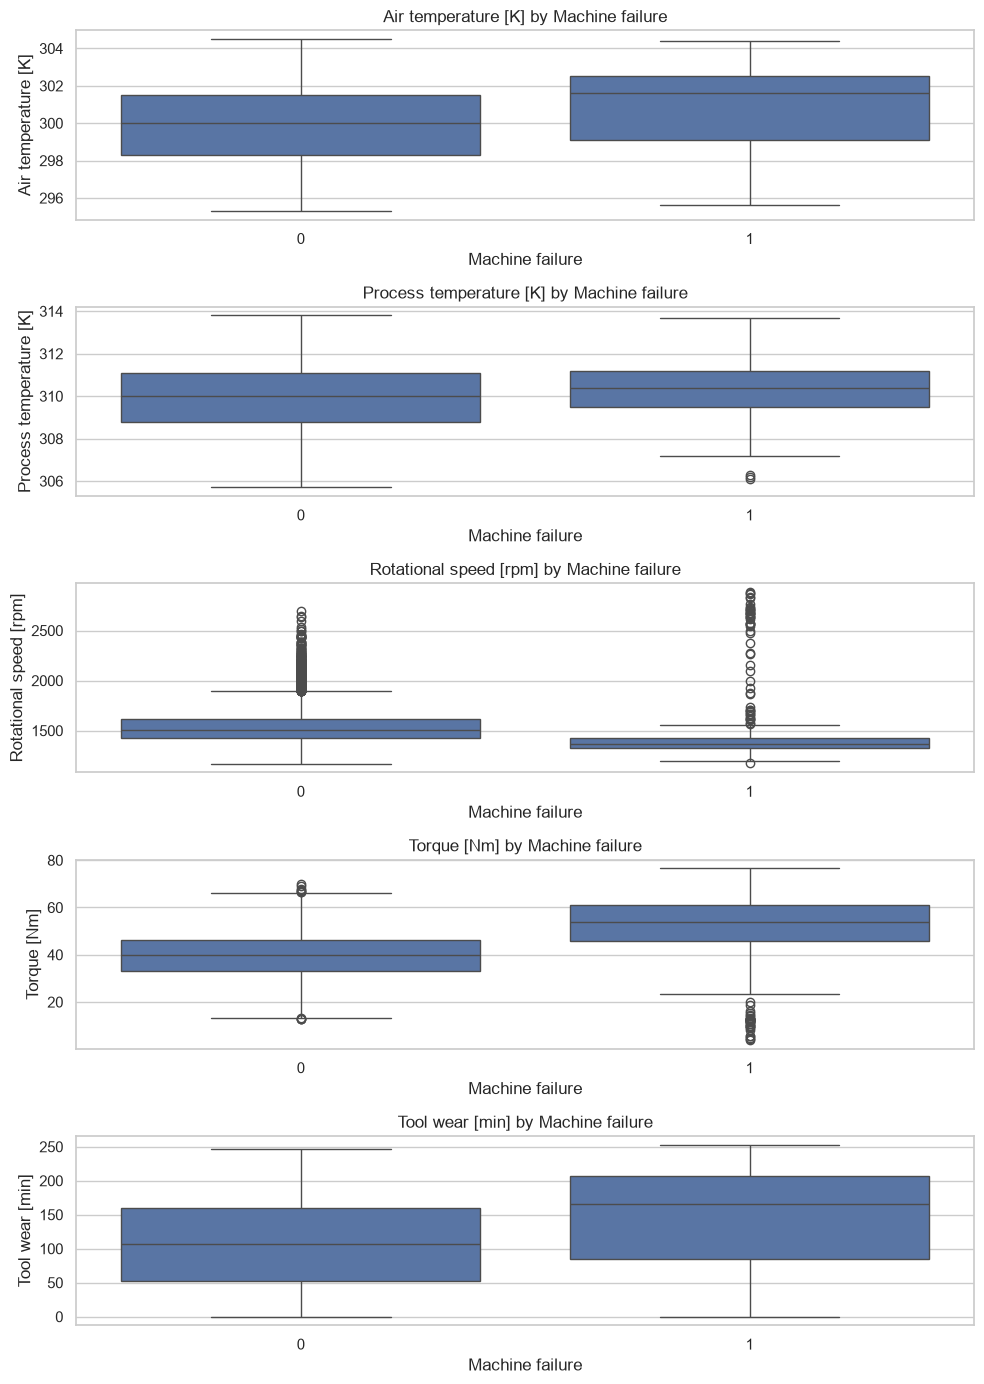

In [14]:
fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(10, 14), sharex=False)

for ax, col in zip(axes, sensor_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by Machine failure")

plt.tight_layout()
plt.show()

## 11. Feature ung vien cho fuzzy system

Phase 1 chi lap danh sach feature co kha nang dung. Chua viet rules.

Goi y can can nhac:
- `Air temperature [K]`
- `Process temperature [K]`
- `Rotational speed [rpm]`
- `Torque [Nm]`
- `Tool wear [min]`

Ly do: day la cac bien numeric/continuous hoac ordinal-like, phu hop hon cho membership functions so voi ID. Cot `Type` co the dung sau neu can bo sung thong tin category, nhung de giu Phase 2 don gian nen uu tien 3-5 sensor numeric truoc.


In [15]:
candidate_features = sensor_cols.copy()
id_cols = ["UDI", "Product ID"]
categorical_cols = ["Type"]

summary = pd.DataFrame({
    "candidate_feature": candidate_features,
    "dtype": [str(df[col].dtype) for col in candidate_features],
    "min": [df[col].min() for col in candidate_features],
    "max": [df[col].max() for col in candidate_features],
    "corr_with_machine_failure": [corr.loc[col, target_col] for col in candidate_features],
})

summary

,candidate_feature,dtype,min,max,corr_with_machine_failure
0,Air temperature [K],float64,295.3,304.5,0.082556
1,Process temperature [K],float64,305.7,313.8,0.035946
2,Rotational speed [rpm],int64,1168.0,2886.0,-0.044188
3,Torque [Nm],float64,3.8,76.6,0.191321
4,Tool wear [min],int64,0.0,253.0,0.105448


## Checkpoint Phase 1

Dung tai day va gui lai cac ket qua sau:

1. `df.shape`
2. Danh sach columns
3. Bang missing values
4. So duplicate rows
5. Class distribution cua `Machine failure`
6. Failure mode counts: `TWF`, `HDF`, `PWF`, `OSF`, `RNF`
7. Bang descriptive statistics cua `sensor_cols`
8. Bang correlation voi `Machine failure`
9. Nhan xet ngan: feature nao co ve phu hop nhat cho fuzzy system ban dau

Sau khi checkpoint nay on, moi chuyen sang Phase 2 - Static Fuzzy System.


## 10. Experimental Data Protocol


In [30]:
display(df["UDI"].head(10))
display(df["UDI"].tail(10))


,UDI
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


,UDI
9990,9991
9991,9992
9992,9993
9993,9994
9994,9995
9995,9996
9996,9997
9997,9998
9998,9999
9999,10000


In [31]:
df["UDI"].is_monotonic_increasing


True

In [32]:
n = len(df)

train_end = int(n * 0.6)
val_end = int(n * 0.8)

print("Total:", n)
print("Train:", train_end)
print("Validation:", val_end - train_end)
print("Test:", n - val_end)


Total: 10000
Train: 6000
Validation: 2000
Test: 2000
